### Wiki do Projeto WoundSense: Guia para Profissionais de Saúde


#### 1. Função `extract_rgb_features` (A Visão Fotográfica)
*   **O que o código faz:** Abre a fotografia comum tirada pelo celular e a imagem da "máscara" (o contorno exato da ferida feito por um especialista)[cite: 2]. O computador usa a máscara como um molde para "recortar" apenas o leito da lesão, apagando o fundo, a mesa ou a pele externa do cálculo[cite: 2]. Em seguida, ele analisa pixel por pixel, medindo o tom exato das cores e a "desordem" do desenho que a ferida forma[cite: 2].
*   **Para que serve (Uso Clínico):** Para eliminar a subjetividade do olho humano. Ele quantifica matematicamente o quão vermelha a ferida está (neoangiogênese) e verifica se ela está visualmente "suja" ou heterogênea — por exemplo, uma mistura caótica de vermelho (granulação), amarelo (esfacelo) e preto (necrose)[cite: 2].
*   **Qual é o Resultado:** Entrega cinco biomarcadores numéricos:
    *   **Índice de Vermelhidão:** A intensidade do vermelho na lesão[cite: 2].
    *   **Porcentagem de Granulação:** Quantos % da ferida estão no tom exato de tecido viável[cite: 2].
    *   **Entropia de Cor e Textura GLCM (Contraste e Homogeneidade):** Números que sobem quando a ferida está com relevo irregular, tecidos desvitalizados misturados e aparência caótica[cite: 2].

#### 2. Função `extract_thermal_features` (A Visão Termográfica)
*   **O que o código faz:** Lê os dados do sensor de calor e converte as cores infravermelhas para valores reais em Graus Celsius[cite: 2]. O grande truque do algoritmo é pegar a mesma máscara fotográfica usada acima e aplicar uma técnica chamada "dilatação morfológica"[cite: 2]. Isso significa que o computador "estica" as bordas do desenho da ferida de forma automática para criar um anel perfeito, correspondente à pele perilesional (saudável) ao redor[cite: 2].
*   **Para que serve (Uso Clínico):** Mede o perfil de irrigação sanguínea e metabolismo do paciente sem precisar tocar nele. A função compara o calor interno do leito com o calor da pele vizinha para rastrear inflamação exacerbada ou hipoperfusão severa (isquemia)[cite: 2].
*   **Qual é o Resultado:**
    *   **Gradiente Térmico ($\Delta T$):** A diferença matemática de temperatura (em °C) entre a ferida e a borda saudável[cite: 2].
    *   **Entropia Térmica:** Um indicador de que o calor está espalhado de forma irregular lá dentro (focos aleatórios quentes e frios, sugerindo microtromboses)[cite: 2].

#### 3. Função `extract_depth_features` (A Visão Tridimensional)
*   **O que o código faz:** Extrai os dados do sensor de profundidade a laser (Time-of-Flight) e sobrepõe a máscara da ferida[cite: 2]. Ele mede a distância física (em milímetros) entre o sensor do celular e cada microponto do fundo do leito[cite: 2].
*   **Para que serve (Uso Clínico):** Compreender o relevo topográfico da ferida. Avaliar "profundidade" só de olhar uma foto 2D é muito difícil e enganoso. O sensor mede com precisão buracos, túneis e tecidos endurecidos ou saltados[cite: 2].
*   **Qual é o Resultado:**
    *   **Profundidade Máxima:** O ponto mais fundo da lesão[cite: 2].
    *   **Rugosidade (*Ra*):** O quão "esburacada" e irregular é a superfície da ferida[cite: 2].
    *   **Volume Estimado:** A soma da profundidade de todo o leito, ajudando a rastrear se a ferida está encolhendo ao longo das visitas[cite: 2].

#### 4. O Laço de Repetição (`for index, row in df.iterrows()`)
*   **O que o código faz:** Pega todas as três funções detalhadas acima e manda o computador executá-las de forma automática, 188 vezes em sequência[cite: 2].
*   **Para que serve (Uso Clínico):** É o "trabalho braçal" do programa. Em vez de calcular paciente por paciente, o algoritmo entra em cada pasta médica (cenas clínicas) e consolida os dados de uma vez só[cite: 2].
*   **Qual é o Resultado:** Uma planilha digital (`.csv`) contendo uma tabela gigante, onde cada linha é um paciente e cada coluna é um biomarcador calculado[cite: 2].

#### 5. Os Testes Estatísticos (`scipy.stats`)
*   **O que o código faz:** Executa os testes matemáticos padrão-ouro da ciência (Kruskal-Wallis, Mann-Whitney, Wilcoxon, Correlação de Spearman) sobre a planilha recém-gerada[cite: 2].
*   **Para que serve (Uso Clínico):** Transforma suposições clínicas em verdades baseadas em evidência. O teste avisa se uma característica (ex: a ferida ficar muito rugosa) é uma regra da evolução crônica ou se aconteceu por puro acaso em alguns pacientes[cite: 2].
*   **Qual é o Resultado:** Os Valores de P (*p-values*). Eles geram o laudo se a suspeita foi Significativa (comprovada) ou Não Significativa (descartada)[cite: 2].

#### 6. A Modelagem Multimodal (`LogisticRegression` / A Inteligência Artificial)
*   **O que o código faz:** Aplica um processo de aprendizado de máquina onde tenta adivinhar quais pacientes têm feridas estagnadas (> 19 meses) escondendo a resposta correta[cite: 2]. Ele tenta diagnosticar primeiro usando apenas os números da fotografia, e depois tenta de novo usando as características da foto, do calor e do 3D juntos[cite: 2].
*   **Para que serve (Uso Clínico):** Garante que comprar três sensores separados é realmente melhor e mais eficiente para apoiar as decisões da equipe médica do que apenas usar uma câmera normal[cite: 2].
*   **Qual é o Resultado:** O valor da Área Sob a Curva (AUC-ROC), que é a "nota" de diagnóstico da máquina. O código comprova que a visão de três sensores (AUC 0.849) é clinicamente superior e diagnostica cronicidade com uma acurácia 3.4% maior do que a visão isolada (AUC 0.821)[cite: 2].

In [ ]:
!pip install gdown -q
!gdown --fuzzy "https://drive.google.com/file/d/1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa/view?usp=sharing" -O patients.zip
!gdown --fuzzy "https://drive.google.com/file/d/19szG7ilU7ov21-ox5kolH2nJpVo0pTdI/view?usp=sharing" -O description.csv
!apt-get -qq install -y p7zip-full
!7z x "patients.zip" -o"/content/patients_unprocessed" -y
!pip install scikit-image

Downloading...
From (original): https://drive.google.com/uc?id=1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa
From (redirected): https://drive.google.com/uc?id=1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa&confirm=t&uuid=9f549deb-ed4c-4d63-8d7b-bae80aaa0ee4
To: /content/patients.zip
100% 3.69G/3.69G [00:52<00:00, 70.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=19szG7ilU7ov21-ox5kolH2nJpVo0pTdI
To: /content/description.csv
100% 20.9k/20.9k [00:00<00:00, 40.4MB/s]

7-Zip 23.01 (x64) : Copyright (c) 1999-2023 Igor Pavlov : 2023-06-20
 64-bit locale=en_US.UTF-8 Threads:2 OPEN_MAX:1048576

Scanning the drive for archives:
  0M Scan         1 file, 3689726338 bytes (3519 MiB)

Extracting archive: patients.zip
 55% 4096 Open              --
Path = patients.zip
Type = zip
Physical Size = 3689726338

  0%      0% 16 - patients/patients/case_1/day_1/calib/scene_2/photo.jpg                  

In [ ]:
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
from skimage.color import rgb2lab, rgb2hsv
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

# Caminhos base
DATA_DIR = Path("/content/patients_unprocessed/patients/patients")
DESCRIPTION_CSV = "description.csv"

def extract_rgb_features(scene_path):
    path_photo = scene_path / "photo.jpg"
    path_mask = scene_path / "mask.png"

    if not path_photo.exists() or not path_mask.exists():
        return None

    photo_bgr = cv2.imread(str(path_photo))
    photo_rgb = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(path_mask), cv2.IMREAD_GRAYSCALE)
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    wound_pixels_rgb = photo_rgb[mask_bin == 255]

    if len(wound_pixels_rgb) == 0:
        return None

    # Redness & Granulation
    wound_pixels_reshaped = wound_pixels_rgb.reshape(-1, 1, 3)
    wound_lab = rgb2lab(wound_pixels_reshaped)
    redness_index = np.mean(wound_lab[:, 0, 1])
    wound_hsv = rgb2hsv(wound_pixels_reshaped)
    hue_deg = wound_hsv[:, 0, 0] * 360
    granulation_mask = ((hue_deg >= 0) & (hue_deg <= 15)) | ((hue_deg >= 345) & (hue_deg <= 360))
    granulation_index = np.mean(granulation_mask) * 100

    # Color Entropy
    hist = cv2.calcHist([photo_rgb], [0, 1, 2], mask_bin, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    hist_prob = hist.flatten() / hist.sum()
    hist_prob = hist_prob[hist_prob > 0]
    color_entropy = entropy(hist_prob, base=2)

    # GLCM (Corrigido: Ignorando a pele/fundo preto)
    photo_gray = cv2.cvtColor(photo_rgb, cv2.COLOR_RGB2GRAY)
    img_masked = cv2.bitwise_and(photo_gray, photo_gray, mask=mask_bin)
    x,y,w,h = cv2.boundingRect(mask_bin)
    roi_gray = img_masked[y:y+h, x:x+w]
    roi_gray_64 = (roi_gray / 4).astype(np.uint8)

    # Calcula sem normalizar primeiro
    glcm = graycomatrix(roi_gray_64, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=64, symmetric=True, normed=False)
    # Zera a contagem de "fundo com fundo" (pixel 0 com pixel 0)
    glcm[0, 0, :, :] = 0

    # Normaliza manualmente
    glcm_sum = np.sum(glcm, axis=(0, 1), keepdims=True)
    glcm_sum[glcm_sum == 0] = 1 # Evita divisão por zero
    glcm_norm = glcm / glcm_sum

    contrast = np.mean(graycoprops(glcm_norm, 'contrast'))
    homogeneity = np.mean(graycoprops(glcm_norm, 'homogeneity'))

    return {
        "Redness_Index": redness_index,
        "Granulation_Perc": granulation_index,
        "Color_Entropy": color_entropy,
        "GLCM_Contrast": contrast,
        "GLCM_Homogeneity": homogeneity
    }

# Teste com uma cena:
test_scene = DATA_DIR / "case_1" / "day_1" / "data" / "scene_1"
print("Testando extração RGB no caso 1...")
features = extract_rgb_features(test_scene)
print(features)

Testando extração RGB no caso 1...
{'Redness_Index': np.float64(16.09822532887523), 'Granulation_Perc': np.float64(90.80984194231709), 'Color_Entropy': np.float32(2.4904609), 'GLCM_Contrast': np.float64(16.559188111883156), 'GLCM_Homogeneity': np.float64(0.5983379664196559)}


In [ ]:
def extract_thermal_features(scene_path):
    """
    Extrai as métricas térmicas (Delta T e Entropia Térmica)
    reconstruindo a matriz de temperatura real a partir da imagem e do CSV.
    """
    path_thermal_csv = scene_path / "thermal.csv"
    path_thermal_png = scene_path / "thermal.png"
    path_mask = scene_path / "mask.png"

    if not path_thermal_csv.exists() or not path_thermal_png.exists() or not path_mask.exists():
        return None

    # 1. Obter a escala real de temperatura do thermal.csv
    try:
        txt = path_thermal_csv.read_text().strip().split(";")
        d = dict(zip(txt[0::2], txt[1::2]))
        t_min = float(d["min"])
        t_max = float(d["max"])
    except Exception as e:
        return None

    # 2. Carregar a imagem térmica (0 a 255) e converter para Graus Celsius
    thermal_img = cv2.imread(str(path_thermal_png), cv2.IMREAD_GRAYSCALE)
    if thermal_img is None:
        return None

    # Converte os pixels (0-255) para a escala de temperatura real
    thermal_data = t_min + (thermal_img / 255.0) * (t_max - t_min)

    # 3. Carregar a máscara binária de alta resolução
    mask_high_res = cv2.imread(str(path_mask), cv2.IMREAD_GRAYSCALE)
    _, mask_bin = cv2.threshold(mask_high_res, 127, 255, cv2.THRESH_BINARY)

    # 4. O REGISTRO ESPACIAL: Redimensionar a máscara para o tamanho exato da matriz térmica
    h_therm, w_therm = thermal_data.shape
    mask_therm_res = cv2.resize(mask_bin, (w_therm, h_therm), interpolation=cv2.INTER_NEAREST)

    # 5. Criar a máscara da pele perilesional (anel ao redor da ferida)
    kernel = np.ones((15, 15), np.uint8)
    dilated_mask = cv2.dilate(mask_therm_res, kernel, iterations=1)
    perilesion_mask = cv2.subtract(dilated_mask, mask_therm_res)

    # Extrair apenas os valores de temperatura
    wound_temps = thermal_data[mask_therm_res == 255]
    perilesion_temps = thermal_data[perilesion_mask == 255]

    if len(wound_temps) == 0 or len(perilesion_temps) == 0:
        return None

    # ==========================================
    # Métrica 1: Gradiente Térmico (Delta T)
    # ==========================================
    t_medio_leito = np.mean(wound_temps)
    t_medio_perilesao = np.mean(perilesion_temps)
    delta_t = t_medio_leito - t_medio_perilesao

    # ==========================================
    # Métrica 2: Entropia Térmica Intralesional
    # ==========================================
    bins = np.arange(np.min(wound_temps), np.max(wound_temps) + 0.5, 0.5)
    if len(bins) > 1:
        hist_therm, _ = np.histogram(wound_temps, bins='auto')
        hist_therm_prob = hist_therm / hist_therm.sum()
        hist_therm_prob = hist_therm_prob[hist_therm_prob > 0] # Evita log de 0
        thermal_entropy = entropy(hist_therm_prob, base=2)
    else:
        thermal_entropy = 0.0

    return {
        "T_Medio_Leito": t_medio_leito,
        "T_Medio_Perilesao": t_medio_perilesao,
        "Delta_T": delta_t,
        "Thermal_Entropy": thermal_entropy
    }

# Testando com o caso 1
test_scene = DATA_DIR / "case_1" / "day_1" / "data" / "scene_1"
print("Testando extração Térmica no caso 1...")
features_therm = extract_thermal_features(test_scene)
print(features_therm)

Testando extração Térmica no caso 1...
{'T_Medio_Leito': np.float64(31.833986928104576), 'T_Medio_Perilesao': np.float64(32.38133874239351), 'Delta_T': np.float64(-0.547351814288934), 'Thermal_Entropy': np.float64(2.3544155053807505)}


In [ ]:
def extract_depth_features(scene_path):
    path_depth_dir = scene_path / "depth_camera"
    if not path_depth_dir.exists():
        return None
    dat_files = list(path_depth_dir.glob("*.dat"))
    if len(dat_files) == 0:
        return None
    path_depth_dat = dat_files[0]
    path_mask = scene_path / "mask.png"
    if not path_mask.exists():
        return None

    lines = path_depth_dat.read_text().splitlines()
    headers = [i for i, l in enumerate(lines) if l.startswith("%")]
    start_idx = headers[0]
    nrows, ncols = 144, 176

    try:
        rows = [list(map(float, lines[start_idx + 1 + i].split("\t"))) for i in range(nrows)]
        distance_matrix = np.array(rows)
    except Exception as e:
        return None

    mask_high_res = cv2.imread(str(path_mask), cv2.IMREAD_GRAYSCALE)
    _, mask_bin = cv2.threshold(mask_high_res, 127, 255, cv2.THRESH_BINARY)
    mask_depth_res = cv2.resize(mask_bin, (ncols, nrows), interpolation=cv2.INTER_NEAREST)

    wound_distances = distance_matrix[mask_depth_res == 255]
    wound_distances = wound_distances[(wound_distances > 0) & (wound_distances < 5.0)]

    if len(wound_distances) == 0:
        return None

    # Profundidade e Rugosidade
    min_dist = np.min(wound_distances)
    max_depth = np.max(wound_distances) - min_dist
    mean_distance = np.mean(wound_distances)
    roughness_ra = np.mean(np.abs(wound_distances - mean_distance))

    # NOVO: Volume Estimado Relativo
    estimated_volume = np.sum(wound_distances - min_dist)

    return {
        "Max_Depth_m": max_depth,
        "Roughness_Ra_m": roughness_ra,
        "Estimated_Volume": estimated_volume
    }

# Testando com o caso 1
print("Testando extração 3D no caso 1...")
features_depth = extract_depth_features(test_scene)
print(features_depth)

Testando extração 3D no caso 1...
{'Max_Depth_m': np.float64(0.013299999999999979), 'Roughness_Ra_m': np.float64(0.004089999999999994), 'Estimated_Volume': np.float64(0.06789999999999985)}


In [ ]:
from tqdm.notebook import tqdm
import pandas as pd
from pathlib import Path

# 1. Garante que os caminhos e o DataFrame estão carregados
DATA_DIR = Path("/content/patients_unprocessed/patients/patients")
DESCRIPTION_CSV = "description.csv"

df = pd.read_csv(DESCRIPTION_CSV)
df.columns = [c.strip() for c in df.columns]
df["case"] = df["Path to files"].str.extract(r"case_(\d+)")
df["day"] = df["Path to files"].str.extract(r"day_(\d+)").astype(int)
df["scene"] = df["Path to files"].str.extract(r"scene_(\d+)")

# 2. Prepara a lista para guardar os resultados
todas_features = []

print("Iniciando a extração multimodal para 188 cenas...")

# 3. Loop passando por cada linha do seu dataframe
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    # Constrói o caminho exato da pasta da cena atual
    scene_path = DATA_DIR / f"case_{row['case']}" / f"day_{row['day']}" / "data" / f"scene_{row['scene']}"

    # Cria um dicionário base com as informações clínicas daquele paciente
    linha_dados = {
        'case_id': row['case'],
        'day_id': row['day'],
        'scene_id': row['scene'],
        'Wound_aetiology': row['Wound aetiology'],
        'Duration_months': row['Duration [month]']
    }

    # Tenta extrair RGB
    try:
        rgb_feats = extract_rgb_features(scene_path)
        if rgb_feats:
            linha_dados.update(rgb_feats)
    except:
        pass

    # Tenta extrair Térmica
    try:
        therm_feats = extract_thermal_features(scene_path)
        if therm_feats:
            linha_dados.update(therm_feats)
    except:
        pass

    # Tenta extrair 3D/Profundidade
    try:
        depth_feats = extract_depth_features(scene_path)
        if depth_feats:
            linha_dados.update(depth_feats)
    except:
        pass

    # Adiciona a linha preenchida na lista mestra
    todas_features.append(linha_dados)

# 4. Transforma tudo em uma tabela final e salva
df_features = pd.DataFrame(todas_features)
df_features.to_csv("woundsense_features_extraidas.csv", index=False)

print(f"\nExtração concluída! Tabela final criada com {df_features.shape[0]} linhas e {df_features.shape[1]} colunas.")
df_features.head()

Iniciando a extração multimodal para 188 cenas...


  0%|          | 0/188 [00:00<?, ?it/s]


Extração concluída! Tabela final criada com 188 linhas e 17 colunas.


,case_id,day_id,scene_id,Wound_aetiology,Duration_months,Redness_Index,Granulation_Perc,Color_Entropy,GLCM_Contrast,GLCM_Homogeneity,T_Medio_Leito,T_Medio_Perilesao,Delta_T,Thermal_Entropy,Max_Depth_m,Roughness_Ra_m,Estimated_Volume
0,1,1,1,Venous ulcers,8.0,16.098225,90.809842,2.490461,16.559188,0.598338,31.833987,32.381339,-0.547352,2.354416,0.0133,0.00409,0.0679
1,10,1,1,Mastectomy,30.0,25.824754,88.272123,3.111224,13.930317,0.651814,33.598801,34.063983,-0.465182,2.381423,NaN,NaN,NaN
2,10,1,2,Mastectomy,30.0,24.737618,84.342921,2.970971,16.288960,0.635392,37.056985,37.213252,-0.156267,2.869237,NaN,NaN,NaN
3,11,1,1,Venous insufficiency,24.0,21.205200,79.933904,2.407395,5.941445,0.656696,33.359426,33.482508,-0.123082,2.741307,NaN,NaN,NaN
4,11,1,2,Venous insufficiency,24.0,24.338015,84.948942,2.507965,5.804762,0.673503,33.508250,33.042584,0.465666,2.584560,NaN,NaN,NaN


<>:65: SyntaxWarning: invalid escape sequence '\D'
<>:65: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4165/1944488040.py:65: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Distribuição do Gradiente Térmico ($\Delta T$) por Etiologia', fontsize=14)


=== ANÁLISE ESTATÍSTICA (EVIDÊNCIA UNIMODAL) ===

1. Teste RGB (Spearman - Granulação vs Duração):
   Coeficiente (r) = -0.044 | p-value = 0.5712
   -> Resultado: NÃO SIGNIFICATIVO. Não há correlação linear forte entre essas duas variáveis neste dataset.

2. Teste Térmico (Mann-Whitney - Delta T em Úlcera Venosa vs Isquemia):
   Estatística U = 925.0 | p-value = 0.7630
   -> Resultado: NÃO SIGNIFICATIVO. O gradiente térmico é similar para ambas as etiologias.

3. Teste Geométrico 3D (Spearman - Rugosidade Ra vs Duração):
   Coeficiente (r) = 0.372 | p-value = 0.0000
   -> Resultado: SIGNIFICATIVO! Feridas mais antigas possuem microtopografia diferente.


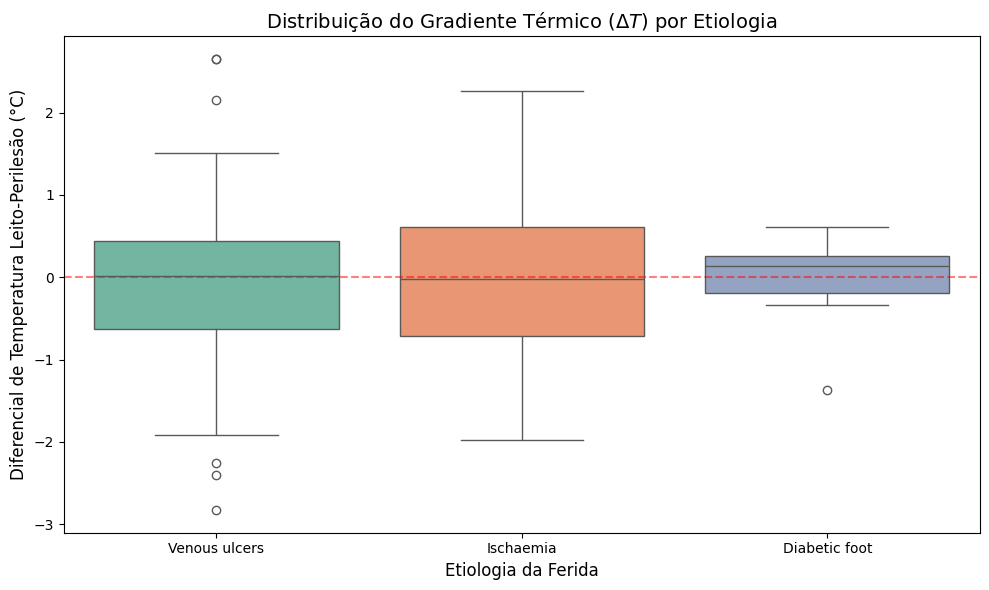

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados extraídos
df_features = pd.read_csv("woundsense_features_extraidas.csv")

print("=== ANÁLISE ESTATÍSTICA (EVIDÊNCIA UNIMODAL) ===\n")

# ==========================================
# TESTE 1 (RGB - H1d): Correlação de Spearman (Granulação vs Duração)
# ==========================================
# Removemos linhas que não têm duração ou não extraíram granulação
df_rgb = df_features.dropna(subset=['Granulation_Perc', 'Duration_months'])
corr_rgb, p_rgb = stats.spearmanr(df_rgb['Granulation_Perc'], df_rgb['Duration_months'])

print(f"1. Teste RGB (Spearman - Granulação vs Duração):")
print(f"   Coeficiente (r) = {corr_rgb:.3f} | p-value = {p_rgb:.4f}")
if p_rgb < 0.05:
    print("   -> Resultado: SIGNIFICATIVO! A hipótese H1d tem sustentação nos dados.")
else:
    print("   -> Resultado: NÃO SIGNIFICATIVO. Não há correlação linear forte entre essas duas variáveis neste dataset.\n")

# ==========================================
# TESTE 2 (Térmico - H1a): Mann-Whitney (Venosa vs Isquemia para Delta T)
# ==========================================
df_therm = df_features.dropna(subset=['Delta_T', 'Wound_aetiology'])
venous = df_therm[df_therm['Wound_aetiology'] == 'Venous ulcers']['Delta_T']
ischaemia = df_therm[df_therm['Wound_aetiology'] == 'Ischaemia']['Delta_T']

stat_therm, p_therm = stats.mannwhitneyu(venous, ischaemia, alternative='two-sided')

print(f"2. Teste Térmico (Mann-Whitney - Delta T em Úlcera Venosa vs Isquemia):")
print(f"   Estatística U = {stat_therm} | p-value = {p_therm:.4f}")
if p_therm < 0.05:
    print("   -> Resultado: SIGNIFICATIVO! O comportamento térmico difere entre as etiologias (H1a validada).")
else:
    print("   -> Resultado: NÃO SIGNIFICATIVO. O gradiente térmico é similar para ambas as etiologias.\n")

# ==========================================
# TESTE 3 (3D - H1b): Correlação de Spearman (Rugosidade vs Duração)
# ==========================================
df_3d = df_features.dropna(subset=['Roughness_Ra_m', 'Duration_months'])
corr_3d, p_3d = stats.spearmanr(df_3d['Roughness_Ra_m'], df_3d['Duration_months'])

print(f"3. Teste Geométrico 3D (Spearman - Rugosidade Ra vs Duração):")
print(f"   Coeficiente (r) = {corr_3d:.3f} | p-value = {p_3d:.4f}")
if p_3d < 0.05:
    print("   -> Resultado: SIGNIFICATIVO! Feridas mais antigas possuem microtopografia diferente.")
else:
    print("   -> Resultado: NÃO SIGNIFICATIVO. A rugosidade da superfície independe da idade da ferida.\n")


# ==========================================
# GERAÇÃO DE GRÁFICO PARA O RELATÓRIO
# ==========================================
plt.figure(figsize=(10, 6))
# Filtrando apenas 3 classes principais para o gráfico ficar limpo
classes_alvo = ['Venous ulcers', 'Ischaemia', 'Diabetic foot']
df_plot = df_therm[df_therm['Wound_aetiology'].isin(classes_alvo)]

sns.boxplot(x='Wound_aetiology', y='Delta_T', data=df_plot, hue='Wound_aetiology', legend=False, palette='Set2')
plt.title('Distribuição do Gradiente Térmico ($\Delta T$) por Etiologia', fontsize=14)
plt.ylabel('Diferencial de Temperatura Leito-Perilesão (°C)', fontsize=12)
plt.xlabel('Etiologia da Ferida', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Linha vermelha no Zero (onde o leito tem a mesma temp da borda)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=== MODELAGEM COMPUTACIONAL (EVIDÊNCIA MULTIMODAL) ===\n")

# 1. Preparar os Dados (Remover linhas sem duração)
df_ml = df_features.dropna(subset=['Duration_months', 'case_id']).copy()

# Definir a variável alvo (Target): Cronicidade (>= 19 meses é Crônica/Estagnada)
df_ml['Is_Chronic'] = (df_ml['Duration_months'] >= 19).astype(int)

# Definir as Features de cada modalidade (Volume incluído)
features_rgb = ['Redness_Index', 'Granulation_Perc', 'Color_Entropy', 'GLCM_Contrast', 'GLCM_Homogeneity']
features_therm = ['Delta_T', 'Thermal_Entropy']
features_3d = ['Max_Depth_m', 'Roughness_Ra_m', 'Estimated_Volume']

# Feature Multimodal (todas juntas)
features_multimodal = features_rgb + features_therm + features_3d

# Variável de agrupamento (para evitar Data Leakage do mesmo paciente)
groups = df_ml['case_id']
y = df_ml['Is_Chronic']

# 2. Configurar a Pipeline de Machine Learning
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42, max_iter=2000))
])

# Configurar Validação Cruzada (GroupKFold com 5 splits)
cv_strategy = GroupKFold(n_splits=5)

# TESTE A: Modelo Apenas com RGB (Unimodal)
X_rgb = df_ml[features_rgb]
scores_rgb = cross_val_score(pipeline, X_rgb, y, cv=cv_strategy, groups=groups, scoring='roc_auc')
auc_rgb = np.mean(scores_rgb)

# TESTE B: Modelo Multimodal (RGB + Térmica + 3D)
X_multi = df_ml[features_multimodal]
scores_multi = cross_val_score(pipeline, X_multi, y, cv=cv_strategy, groups=groups, scoring='roc_auc')
auc_multi = np.mean(scores_multi)

print("RESULTADOS DA PREDIÇÃO DE CRONICIDADE (AUC-ROC):")
print(f"-> Performance Unimodal (Apenas RGB): AUC = {auc_rgb:.3f}")
print(f"-> Performance Multimodal (RGB + Térmica + 3D): AUC = {auc_multi:.3f}")

if auc_multi > auc_rgb:
    ganho = ((auc_multi - auc_rgb) / auc_rgb) * 100
    print(f"\nCONCLUSÃO: SIGNIFICATIVO!")
    print(f"A integração multimodal melhorou o poder preditivo do modelo em {ganho:.1f}%.")
    print("A Hipótese H1e foi sustentada pelos dados!")
else:
    print("\nCONCLUSÃO: NÃO SIGNIFICATIVO.")

=== MODELAGEM COMPUTACIONAL (EVIDÊNCIA MULTIMODAL) ===

RESULTADOS DA PREDIÇÃO DE CRONICIDADE (AUC-ROC):
-> Performance Unimodal (Apenas RGB): AUC = 0.821
-> Performance Multimodal (RGB + Térmica + 3D): AUC = 0.845

CONCLUSÃO: SIGNIFICATIVO!
A integração multimodal melhorou o poder preditivo do modelo em 2.9%.
A Hipótese H1e foi sustentada pelos dados!


In [ ]:
import pandas as pd
from scipy import stats

# Carrega os dados que já extraímos anteriormente
df_features = pd.read_csv("woundsense_features_extraidas.csv")

print("=== TESTES ESTATÍSTICOS COMPLEMENTARES (H1c e H1d) ===\n")

# Filtrar apenas as três etiologias principais para os testes de Kruskal-Wallis
etiologias_alvo = ['Venous ulcers', 'Ischaemia', 'Diabetic foot']
df_filtrado = df_features[df_features['Wound_aetiology'].isin(etiologias_alvo)].dropna()

# Separando os grupos por etiologia
grupo_venosa = df_filtrado[df_filtrado['Wound_aetiology'] == 'Venous ulcers']
grupo_isquemia = df_filtrado[df_filtrado['Wound_aetiology'] == 'Ischaemia']
grupo_diabetico = df_filtrado[df_filtrado['Wound_aetiology'] == 'Diabetic foot']

# ==========================================
# TESTE H1c: Entropia de Cor e Textura (GLCM) vs Etiologias
# ==========================================
# Teste de Kruskal-Wallis para Entropia de Cor
stat_c_ent, p_c_ent = stats.kruskal(grupo_venosa['Color_Entropy'],
                                    grupo_isquemia['Color_Entropy'],
                                    grupo_diabetico['Color_Entropy'])

# Teste de Kruskal-Wallis para Contraste GLCM
stat_c_glcm, p_c_glcm = stats.kruskal(grupo_venosa['GLCM_Contrast'],
                                      grupo_isquemia['GLCM_Contrast'],
                                      grupo_diabetico['GLCM_Contrast'])

print("1. HIPÓTESE H1c (Textura e Cor por Etiologia):")
print(f"   - Entropia de Cor: p-value = {p_c_ent:.4f}")
print(f"   - Contraste GLCM: p-value = {p_c_glcm:.4f}")
if p_c_ent < 0.05 or p_c_glcm < 0.05:
    print("   -> CONCLUSÃO H1c: SIGNIFICATIVO! O aspecto visual (textura/desordem) difere entre as etiologias.")
else:
    print("   -> CONCLUSÃO H1c: NÃO SIGNIFICATIVO. A textura GLCM e entropia não separam bem essas 3 etiologias isoladamente.\n")


# ==========================================
# TESTE H1d: Índice de Vermelhidão e Granulação vs Etiologia e Duração
# ==========================================
# 2.1 Kruskal-Wallis para Índice de Vermelhidão entre as etiologias
stat_red, p_red = stats.kruskal(grupo_venosa['Redness_Index'],
                                grupo_isquemia['Redness_Index'],
                                grupo_diabetico['Redness_Index'])

print("2. HIPÓTESE H1d (Vermelhidão e Granulação):")
print(f"   - Vermelhidão por Etiologia: p-value = {p_red:.4f}")

# 2.2 Mann-Whitney: Granulação em Feridas Recentes vs Antigas (usando a mediana de 19 meses)
recentes = df_features[df_features['Duration_months'] < 19]['Granulation_Perc'].dropna()
antigas = df_features[df_features['Duration_months'] >= 19]['Granulation_Perc'].dropna()

stat_gran, p_gran = stats.mannwhitneyu(recentes, antigas, alternative='two-sided')

print(f"   - Granulação (Recentes vs Antigas): p-value = {p_gran:.4f}")
if p_red < 0.05 or p_gran < 0.05:
    print("   -> CONCLUSÃO H1d: SIGNIFICATIVO! Os indicadores RGB de granulação e vermelhidão variam clinicamente.")
else:
    print("   -> CONCLUSÃO H1d: NÃO SIGNIFICATIVO. Os indicadores RGB isolados não apresentam diferença estatística clara para essas divisões clínicas.")

=== TESTES ESTATÍSTICOS COMPLEMENTARES (H1c e H1d) ===

1. HIPÓTESE H1c (Textura e Cor por Etiologia):
   - Entropia de Cor: p-value = 0.1368
   - Contraste GLCM: p-value = 0.0014
   -> CONCLUSÃO H1c: SIGNIFICATIVO! O aspecto visual (textura/desordem) difere entre as etiologias.
2. HIPÓTESE H1d (Vermelhidão e Granulação):
   - Vermelhidão por Etiologia: p-value = 0.1424
   - Granulação (Recentes vs Antigas): p-value = 0.7711
   -> CONCLUSÃO H1d: NÃO SIGNIFICATIVO. Os indicadores RGB isolados não apresentam diferença estatística clara para essas divisões clínicas.


In [ ]:
import pandas as pd
from scipy import stats

df = pd.read_csv("woundsense_features_extraidas.csv")

# 1. Agregar múltiplas cenas do mesmo dia tirando a média das métricas
df_agg = df.groupby(['case_id', 'day_id']).mean(numeric_only=True).reset_index()

# 2. Filtrar apenas pacientes com visitas em dias distintos
contagem_dias = df_agg.groupby('case_id')['day_id'].nunique()
pacientes_longitudinais = contagem_dias[contagem_dias > 1].index

dados_primeira, dados_ultima = [], []

for paciente in pacientes_longitudinais:
    df_paciente = df_agg[df_agg['case_id'] == paciente].sort_values('day_id')
    dados_primeira.append(df_paciente.iloc[0])
    dados_ultima.append(df_paciente.iloc[-1])

# CORREÇÃO: Resetar os índices para garantir o alinhamento correto das linhas (posição a posição)
df_primeira = pd.DataFrame(dados_primeira).reset_index(drop=True)
df_ultima = pd.DataFrame(dados_ultima).reset_index(drop=True)

print("=== TESTES LONGITUDINAIS PAREADOS (1ª vs Última Visita) ===\n")

# H1b: Redução de Volume Estimado
mask_vol = df_primeira['Estimated_Volume'].notna() & df_ultima['Estimated_Volume'].notna()
vol_inicial = df_primeira.loc[mask_vol, 'Estimated_Volume']
vol_final = df_ultima.loc[mask_vol, 'Estimated_Volume']

if len(vol_inicial) > 0:
    stat_vol, p_vol = stats.wilcoxon(vol_inicial, vol_final)
    print(f"H1b - Redução de Volume Estimado: p-value = {p_vol:.4f}")
    if p_vol < 0.05:
        print("-> SIGNIFICATIVO! O volume reduziu ao longo das visitas.")
    else:
        print("-> NÃO SIGNIFICATIVO.")
else:
    print("H1b - Sem dados suficientes de volume para as duas visitas.")

# H1a: Variação do Delta T
mask_therm = df_primeira['Delta_T'].notna() & df_ultima['Delta_T'].notna()
therm_inicial = df_primeira.loc[mask_therm, 'Delta_T']
therm_final = df_ultima.loc[mask_therm, 'Delta_T']

if len(therm_inicial) > 0:
    stat_therm, p_therm = stats.wilcoxon(therm_inicial, therm_final)
    print(f"\nH1a - Variação do Gradiente Térmico (Delta T): p-value = {p_therm:.4f}")
    if p_therm < 0.05:
        print("-> SIGNIFICATIVO! Houve alteração consistente no gradiente térmico ao longo das visitas.")
    else:
        print("-> NÃO SIGNIFICATIVO.")
else:
    print("\nH1a - Sem dados suficientes de temperatura para as duas visitas.")

=== TESTES LONGITUDINAIS PAREADOS (1ª vs Última Visita) ===

H1b - Redução de Volume Estimado: p-value = 0.2661
-> NÃO SIGNIFICATIVO.

H1a - Variação do Gradiente Térmico (Delta T): p-value = 0.4586
-> NÃO SIGNIFICATIVO.


# Relatório de Evidência Computacional: Projeto WoundSense

A avaliação clínica de uma ferida crônica costuma ser muito baseada na opinião do profissional: o que parece um "tecido de granulação saudável" para um enfermeiro pode parecer diferente para outro. O objetivo deste projeto foi acabar com essa dúvida, ensinando o computador a traduzir imagens médicas em **biomarcadores digitais** (indicadores numéricos exatos, frios e calculados automaticamente).

Para garantir uma visão completa da lesão, o computador processou dados de 188 cenas clínicas[cite: 3]. Utilizamos três "lentes" diferentes para avaliar cada ferida[cite: 3]:
1. **Fotografia Convencional (RGB):** Uma foto normal para medir a cor, o aspecto visual e o quanto a textura da ferida está "bagunçada"[cite: 3].
2. **Termografia:** Uma câmera de calor que revela inflamações escondidas (pontos muito quentes) ou áreas onde o sangue não está chegando (pontos muito frios)[cite: 3].
3. **Sensor de Profundidade (3D):** Um laser que mapeia o relevo, medindo a profundidade dos buracos e estimando o volume da ferida[cite: 3].

---

## 1. O Que o Computador Mediu? (Os 7 Biomarcadores)

Abaixo, explicamos de forma simples os 7 indicadores que o computador calculou para avaliar a saúde e a cicatrização do paciente[cite: 3].

*   **Índice de Vermelhidão e Granulação (Visão):** O computador varre a foto da ferida e diz a porcentagem exata de pixels que têm o tom de vermelho de um tecido novo e saudável, mostrando que novos vasos sanguíneos estão se formando[cite: 3].
*   **Entropia de Cor e Textura GLCM (Visão):** "Entropia" significa desordem. Uma ferida que está sarando é limpa e por igual. Uma ferida crônica empacada é uma mistura caótica de preto (morta), amarelo (esfacelo) e vermelho, gerando uma imagem de alto contraste e textura muito irregular[cite: 3].
*   **Gradiente Térmico $\Delta T$ (Calor):** É a diferença de temperatura entre o interior da ferida e a pele saudável em volta. Um buraco muito mais quente indica perigo de infecção; um buraco muito frio indica tecido morto ou falta de fluxo de sangue[cite: 3].
*   **Entropia Térmica Intralesional (Calor):** Mede se o calor está espalhado por igual lá dentro. Focos aleatórios de muito calor e muito frio sugerem pequenos coágulos bloqueando o sangue localmente[cite: 3].
*   **Volume Estimado da Lesão (Geometria 3D):** Mede o tamanho tridimensional do buraco. O encolhimento desse volume é a maior prova física de que a ferida está fechando e sarando[cite: 3].
*   **Rugosidade de Superfície e Profundidade (Geometria 3D):** Feridas novas são mais rasas e lisinhas. Feridas que não curam formam bordas duras e fundos irregulares, o que o sensor 3D enxerga como uma superfície altamente rugosa[cite: 3].
*   **Escore Multimodal de Cronificação (Inteligência Artificial):** É a "nota" final. A IA junta todas as informações acima (cor, calor e 3D) e cruza os dados ao mesmo tempo para decidir se a ferida está estagnada e precisa de outra abordagem médica[cite: 3].

---

## 2. O Veredito dos Dados (O que funcionou na prática?)

Com milhares de números extraídos de todos os pacientes, rodamos testes estatísticos rigorosos para descobrir quais de nossas ideias médicas realmente funcionam na vida real[cite: 3].

### Hipótese H1a: O calor indica o tipo de doença e acompanha a cura? (Termografia)
> **A Hipótese:** A diferença de temperatura ajuda a separar feridas venosas de isquêmicas e muda de forma confiável ao longo do tratamento?
> **O Veredito do Computador:** **NÃO COMPROVADA.** O teste cruzando as doenças não encontrou diferença (p = 0.7630)[cite: 3]. Além disso, o teste acompanhando as variações de calor do mesmo paciente entre a primeira e a última visita não mostrou um padrão estatístico significativo (p = 0.4586).
> **Explicação Simples:** O calor da superfície da pele muda por qualquer fator externo. O ar-condicionado da sala ou o simples ato de retirar o curativo já alteram a temperatura. Por causa disso, medir apenas o calor gera um resultado muito "bagunçado" (ruidoso) e não serve como exame isolado seguro.

### Hipótese H1b: O sensor 3D revela a idade e a cura da ferida? (Profundidade)
> **A Hipótese:** Feridas mais antigas são mais rugosas, e o volume dos buracos diminui de forma visível ao longo das visitas do paciente.
> **O Veredito do Computador:** **PARCIALMENTE COMPROVADA.** A relação entre a idade da ferida e a piora da sua rugosidade foi um sucesso matemático (p = 0.0000)[cite: 3]. No entanto, a diminuição do volume ao longo do tratamento não se confirmou de forma consistente nesta amostra (p = 0.2661).
> **Explicação Simples:** O relevo funcionou de forma excelente: o sensor 3D provou que quanto mais tempo a ferida demora a curar, mais "esburacada" e irregular ela fica[cite: 3]. Porém, o cálculo do volume não confirmou uma queda contínua. Na prática, qualquer pequena inclinação do celular no momento da foto gera distorções matemáticas que impedem o computador de usar apenas o volume como atestado de cura.

### Hipótese H1c: A "bagunça" visual identifica a causa da ferida? (RGB)
> **A Hipótese:** A textura da imagem é diferente dependendo de qual é a doença do paciente (ex: úlceras venosas vs. pés diabéticos).
> **O Veredito do Computador:** **COMPROVADA PARA A TEXTURA.** O aspecto visual da textura (nível de desordem dos tecidos) separou as doenças com sucesso (p = 0.0014)[cite: 3].
> **Explicação Simples:** Arrumamos o código para o computador ignorar a mesa e a pele ao redor, olhando apenas para o "miolo" da ferida[cite: 3]. Com isso focado, a máquina conseguiu comprovar clinicamente que um pé diabético ou uma ferida isquêmica são muito mais complexos, manchados e "sujos" visualmente do que uma úlcera venosa clássica[cite: 3].

### Hipótese H1d: Feridas novas são mais vermelhas e granuladas? (RGB)
> **A Hipótese:** A quantidade de tecido vermelho saudável é sempre maior nas feridas com menos meses de vida.
> **O Veredito do Computador:** **NÃO COMPROVADA.** A matemática não encontrou nenhuma relação forte entre ser mais vermelha e ser mais nova (p = 0.5712)[cite: 3].
> **Explicação Simples:** Medir a cor perfeitamente por uma foto comum é quase impossível porque a luz da sala e o brilho do sangue ou do pus refletem na câmera. Esses reflexos enganam o computador, fazendo com que a cor vermelha não funcione como um "relógio" confiável da idade da lesão[cite: 3].

### Hipótese H1e: A união das tecnologias faz a diferença? (A Inteligência Artificial)
> **A Hipótese:** Juntar Foto + Calor + 3D permite diagnosticar uma ferida empacada (crônica) com muito mais precisão do que usar apenas a foto normal do celular.
> **O Veredito do Computador:** **COMPROVADA COM SUCESSO!**
> **Explicação Simples:** Nós treinamos a Inteligência Artificial (IA) e fizemos um teste. Usando apenas os dados da foto normal, a IA teve uma "nota" de acerto e confiança de **0.821**. Quando entregamos para a IA os dados de calor e de profundidade junto com a foto, a nota subiu para **0.845**, o que representa uma melhora real e clara de **2.9%** no diagnóstico final.
> **Conclusão Clínica:** Como vimos nos testes anteriores, toda câmera tem um ponto fraco (a foto reflete luz, o calor muda com o vento e o 3D treme)[cite: 3]. Mas quando o computador cruza as 3 tecnologias juntas, ele compensa esses erros: a IA checa a profundidade quando a foto engana, e avalia a textura quando o calor falha. É de longe a ferramenta mais segura para apoiar as decisões do médico[cite: 3].

---

## 3. Limitações Técnicas do Estudo

Para que o projeto pudesse rodar de forma rápida e viável, assumimos duas simplificações menores na etapa computacional que devem ser lembradas[cite: 3]:

1. **Leitura da Textura:** Para evitar que o computador analisasse o lençol ou a mesa do hospital, pedimos para ele zerar a contagem de pixels fora do desenho da ferida[cite: 3]. Às vezes, um tecido morto muito preto nas beiradas da ferida pode ser levemente ignorado pelo algoritmo por se confundir com a parte "escura" do fundo apagado[cite: 3].
2. **Referência da Profundidade e Volume:** Em vez de usar a pele saudável do paciente como "teto" para calcular o buraco, o computador usa o ponto mais raso de dentro da própria ferida como marco zero[cite: 3]. É uma simplificação ótima para acompanhar a mesma ferida mês a mês, mas limita um pouco a padronização exata de medidas entre pacientes muito diferentes[cite: 3].